In [ ]:
%pip install tpot
%pip install lazypredict==0.2.12
%pip install summarytools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 48.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stopit: filename=stopit-1.1.2-py3-none-any.whl size=11938 sha256=bf4a73ecdedcf262598ba1d6e90cde71cf3c55a6f12eece218e50defee6bc8eb
  Stored in directory: /root/.cache/pip/wheels/af/f9/87/bf5b3d565c2a007b4dae9d8142dccc85a9f164e517062dd519
Successfully built stopit
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.8 MB/s eta 0:00:00
  Created wheel for summarytools: filename

In [ ]:
%pip install joblib
import joblib
import tpot
from google.colab import drive
drive.mount('/content/drive')
# from lazypredict.Supervised import LazyClassifier
from sklearn.preprocessing import LabelEncoder

Mounted at /content/drive


In [ ]:
!pip show lazypredict

Name: lazypredict
Version: 0.2.12
Summary: Lazy Predict help build a lot of basic models without much code and helps understand which models works better without any parameter tuning
Home-page: https://github.com/shankarpandala/lazypredict
Author: Shankar Rao Pandala
Author-email: shankar.pandala@live.com
License: MIT license
Location: /usr/local/lib/python3.10/dist-packages
Requires: click, joblib, lightgbm, pandas, scikit-learn, tqdm, xgboost
Required-by: 


In [ ]:
%cd /usr/local/lib/python3.10/dist-packages/lazypredict

/usr/local/lib/python3.10/dist-packages/lazypredict


In [ ]:
%ls

cli.py  __init__.py  __pycache__/  Supervised.py


In [ ]:
file_path = '/usr/local/lib/python3.10/dist-packages/lazypredict/Supervised.py'  # Reemplaza con la ruta real de tu archivo
with open(file_path, 'r') as file:
    content = file.read()

# Muestra el contenido del archivo
print(content)

content = content.replace("sparse", "sparse_output")

# Guarda los cambios
with open(file_path, 'w') as file:
    file.write(content)

"""
Supervised Models
"""
# Author: Shankar Rao Pandala <shankar.pandala@live.com>

import numpy as np
import pandas as pd
from tqdm import tqdm
import datetime
import time
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import all_estimators
from sklearn.base import RegressorMixin
from sklearn.base import ClassifierMixin
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    r2_score,
    mean_squared_error,
)
import warnings
import xgboost

# import catboost
import lightgbm

warnings.filterwarnings("ignore")
pd.set_option("display.precision", 2)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

removed_classifiers = [
    "ClassifierChain",
    "ComplementNB",
    "GradientBoostingClassifier",
    "GaussianProcessClassifie

In [ ]:
import lazypredict
from summarytools import dfSummary

In [ ]:
from lazypredict.Supervised import LazyClassifier

In [ ]:
import numpy as np
import tpot

## Data loading

---



### Simple imputed

In [ ]:
microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed =joblib.load( '/content/drive/MyDrive/FPS/PEANUT/analysis/data_outputs/microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.joblib')

### Not imputed

In [ ]:
microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed =joblib.load( '/content/drive/MyDrive/FPS/PEANUT/analysis/data_outputs/microbiology_icu_charlson_lab_sofa_vitals_urinedf_not_imputed.joblib')

ModuleNotFoundError: No module named 'pandas.core.indexes.numeric'

In [ ]:
import pandas as pd

In [ ]:
pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199

In [ ]:
microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.describe(include = 'object')

,spec_type_desc,gender,race,myocardial_infarct,congestive_heart_failure,peripheral_vascular_disease,cerebrovascular_disease,dementia,chronic_pulmonary_disease,rheumatic_disease,peptic_ulcer_disease,mild_liver_disease,diabetes_without_cc,diabetes_with_cc,paraplegia,renal_disease,malignant_cancer,severe_liver_disease,metastatic_solid_tumor,aids,sample_origin,day_of_week_icu_admission,month_icu_admission,day_of_week_culture_request,month_culture_request,origin
count,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530,5530
unique,31,2,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,31,7,12,7,12,6
top,SPUTUM,M,WHITE,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,SPUTUM,Wednesday,June,Friday,June,Bloque 6
freq,2236,3098,3583,4615,3771,4838,4426,5307,3844,5328,5349,4725,4087,4953,5007,4221,4885,5167,5265,5483,2236,816,500,824,494,2354


In [ ]:
microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.columns[microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.isnull().any()].tolist()  # to get a list instead of an Index object


[]

#### Lazy predict

In [ ]:
from sklearn.model_selection import train_test_split
X= microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.loc[:, microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.columns != 'interpretation']
y = np.array(microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed['interpretation'])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.75, test_size=0.25, random_state=42)
y_train = LabelEncoder().fit_transform(y_train.astype('str'))
y_test = LabelEncoder().fit_transform(y_test.astype('str'))

In [ ]:
print("Train set size: ", X_train.shape)
print("Test set size: ", X_test.shape)

Train set size:  (4147, 62)
Test set size:  (1383, 62)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)

models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Print the Models
print(models)

 97%|█████████▋| 28/29 [00:23<00:00,  1.87it/s]

[LightGBM] [Info] Number of positive: 1458, number of negative: 2689
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4007
[LightGBM] [Info] Number of data points in the train set: 4147, number of used features: 98
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.351579 -> initscore=-0.612104
[LightGBM] [Info] Start training from score -0.612104


100%|██████████| 29/29 [00:24<00:00,  1.19it/s]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
LGBMClassifier                     0.76               0.71     0.71      0.75   
XGBClassifier                      0.74               0.69     0.69      0.74   
NuSVC                              0.75               0.69     0.69      0.74   
BaggingClassifier                  0.75               0.69     0.69      0.74   
AdaBoostClassifier                 0.74               0.68     0.68      0.73   
LinearDiscriminantAnalysis         0.74               0.68     0.68      0.73   
CalibratedClassifierCV             0.74               0.68     0.68      0.73   
RidgeClassifier                    0.74               0.68     0.68      0.73   
RandomForestClassifier             0.75               0.67     0.67      0.74   
LogisticRegression                 0.74               0.67     0.67      0.73   
QuadraticDiscriminantAnalysi

In [ ]:
X_train

array([[1.289e+01, 1.312e+01, 8.189e+01, ..., 5.366e-02, 2.309e-01,
        6.915e-02],
       [1.340e+01, 2.052e+01, 8.864e+01, ..., 2.051e-01, 3.585e-01,
        1.109e-01],
       [1.296e+01, 1.829e+01, 8.418e+01, ..., 6.608e-02, 3.207e-01,
        7.247e-02],
       ...,
       [1.429e+01, 1.682e+01, 9.030e+01, ..., 3.333e-02, 2.458e-01,
        6.120e-02],
       [1.398e+01, 1.962e+01, 9.112e+01, ..., 1.827e-01, 3.179e-01,
        1.055e-01],
       [1.218e+01, 2.052e+01, 7.722e+01, ..., 7.431e-02, 2.694e-01,
        6.878e-02]])

In [ ]:
for feature in microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed.columns:
    if microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed[feature].dtype == 'object':
        microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed[feature] = pd.Categorical(microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed[feature]).codes

In [ ]:
for feature in microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.columns:
    if microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed[feature].dtype == 'object':
        microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed[feature] = pd.Categorical(microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed[feature]).codes

In [ ]:
print(__doc__)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# To use this experimental feature, we need to explicitly ask for it:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.datasets import fetch_california_housing
from sklearn.impute import SimpleImputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

N_SPLITS = 5

rng = np.random.RandomState(0)


X_missing= microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed.loc[:, microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed.columns != 'interpretation']
y_missing = np.array(microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_not_imputed['interpretation'])



# ~2k samples is enough for the purpose of the example.
# Remove the following two lines for a slower run with different error bars.
X_full= microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.loc[:, microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed.columns != 'interpretation']
y_full = np.array(microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_simple_imputed['interpretation'])
n_samples, n_features = X_full.shape

# Estimate the score on the entire dataset, with no missing values
br_estimator = BayesianRidge()
score_full_data = pd.DataFrame(
    cross_val_score(
        br_estimator, X_full, y_full, scoring='neg_mean_squared_error',
        cv=N_SPLITS
    ),
    columns=['Full Data']
)


# Estimate the score after imputation (mean and median strategies)
score_simple_imputer = pd.DataFrame()
for strategy in ('mean', 'median'):
    estimator = make_pipeline(
        SimpleImputer(missing_values=np.nan, strategy=strategy),
        br_estimator
    )
    score_simple_imputer[strategy] = cross_val_score(
        estimator, X_missing, y_missing, scoring='neg_mean_squared_error',
        cv=N_SPLITS
    )

# Estimate the score after iterative imputation of the missing values
# with different estimators
estimators = [
    DecisionTreeRegressor(max_features='sqrt', random_state=0),
    ExtraTreesRegressor(n_estimators=10, random_state=0),
    KNeighborsRegressor(n_neighbors=5)
]
score_iterative_imputer = pd.DataFrame()
for impute_estimator in estimators:
    estimator = make_pipeline(
        IterativeImputer(random_state=0, estimator=impute_estimator),
        br_estimator
    )
    score_iterative_imputer[impute_estimator.__class__.__name__] = \
        cross_val_score(
            estimator, X_missing, y_missing, scoring='neg_mean_squared_error',
            cv=N_SPLITS
        )

scores = pd.concat(
    [score_full_data, score_simple_imputer, score_iterative_imputer],
    keys=['Original', 'SimpleImputer', 'IterativeImputer'], axis=1
)



Automatically created module for IPython interactive environment


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py", line 471, in fit
    Xt = self._fit(X, y, routed_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py", line 408, in _fit
    X, fitted_transformer = fit_transform_one_cached(
  File "/usr/local/lib/python3.10/dist-packages/joblib/memory.py", line 353

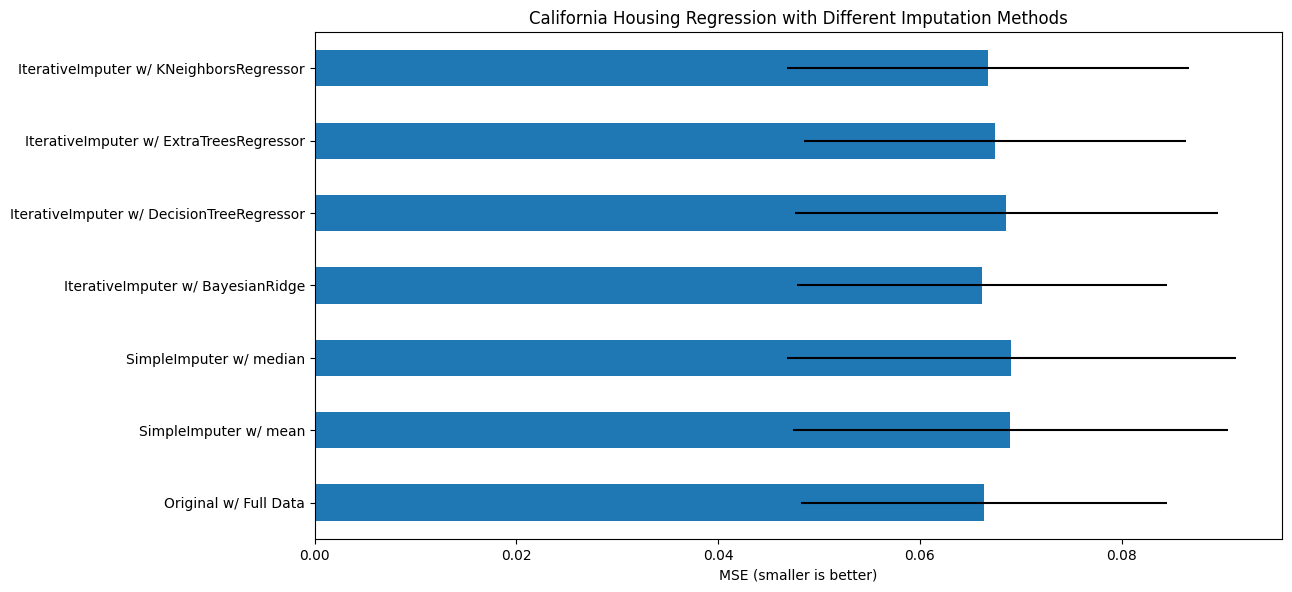

In [ ]:
# plot california housing results
fig, ax = plt.subplots(figsize=(13, 6))
means = -scores.mean()
errors = scores.std()
means.plot.barh(xerr=errors, ax=ax)
ax.set_title(' Antimicrobial Resistance Classification with Different Imputation Methods')
ax.set_xlabel('MSE (smaller is better)')
ax.set_yticks(np.arange(means.shape[0]))
ax.set_yticklabels([" w/ ".join(label) for label in means.index.tolist()])
plt.tight_layout(pad=1)
plt.show()

In [ ]:
joblib.dump(microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_better_imputer, '/content/drive/MyDrive/FPS/PEANUT/analysis/data_outputs/microbiology_icu_charlson_lab_sofa_vitals_urinedf_by_stay_id_better_imputer.joblib')